# Case Study : 1. Handwritten Digit Recognition using MNIST

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
# Normalize data (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0


In [4]:
# Build model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Convert 2D → 1D
    keras.layers.Dense(128, activation='relu'),  # Hidden layer
    keras.layers.Dense(10, activation='softmax') # Output layer (0–9)
])


c:\Users\Dell\Desktop\DATA\tf_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [11]:

# Train model
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9890 - loss: 0.0355 - val_accuracy: 0.9749 - val_loss: 0.0848
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9915 - loss: 0.0281 - val_accuracy: 0.9790 - val_loss: 0.0752
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - accuracy: 0.9930 - loss: 0.0229 - val_accuracy: 0.9756 - val_loss: 0.0811
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9942 - loss: 0.0187 - val_accuracy: 0.9792 - val_loss: 0.0778
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9954 - loss: 0.0151 - val_accuracy: 0.9791 - val_loss: 0.0781
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9958 - loss: 0.0131 - val_accuracy: 0.9794 - val_loss: 0.0749
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9961 - loss: 0.0117 - val_accuracy: 0.9779 - val_loss: 0.0856
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9972 - loss: 0.0

In [12]:
# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9776 - loss: 0.0971


In [13]:

print("Test Accuracy:", test_acc)

# Prediction
predictions = model.predict(x_test)


Test Accuracy: 0.9775999784469604
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


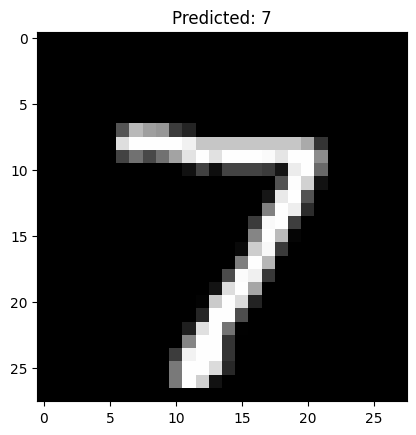

In [14]:
# Show prediction for first image
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predictions[0].argmax()}")
plt.show()

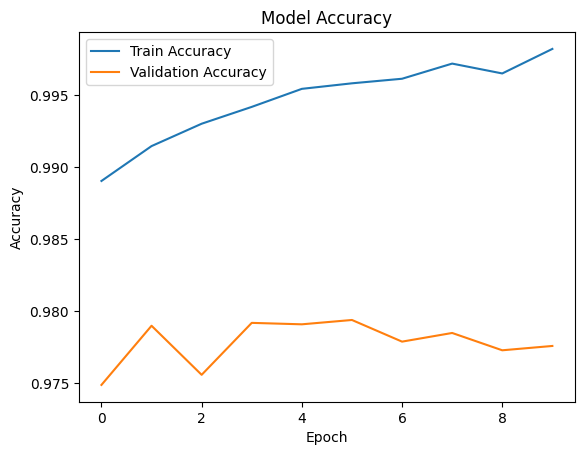

In [15]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()



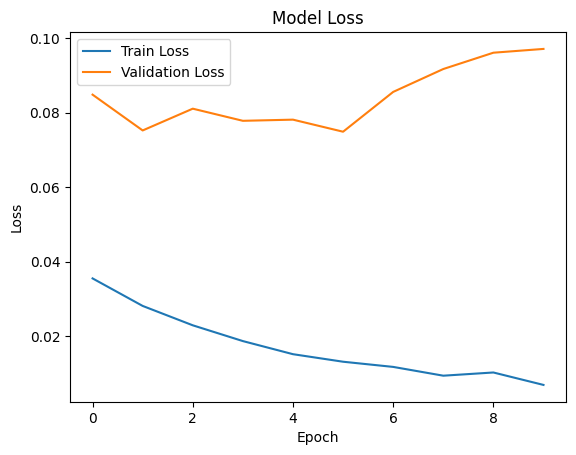

In [16]:
# Loss graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()